# Data Cleaning and Preprocessing

Import files

In [1]:
#importing dataset
import pandas as pd
import numpy as np

df = pd.read_csv("road_accident_dataset.csv")

In [3]:
print(df.isnull().sum())

Country                        0
Year                           0
Month                          0
Day of Week                    0
Time of Day                    0
Urban/Rural                    0
Road Type                      0
Weather Conditions             0
Visibility Level               0
Number of Vehicles Involved    0
Speed Limit                    0
Driver Age Group               0
Driver Gender                  0
Driver Alcohol Level           0
Driver Fatigue                 0
Vehicle Condition              0
Pedestrians Involved           0
Cyclists Involved              0
Accident Severity              0
Number of Injuries             0
Number of Fatalities           0
Emergency Response Time        0
Traffic Volume                 0
Road Condition                 0
Accident Cause                 0
Insurance Claims               0
Medical Cost                   0
Economic Loss                  0
Region                         0
Population Density             0
dtype: int

**Observation**: There are no found missing values in this dataset

In [4]:
df.duplicated().sum()

np.int64(0)

**Observation**: There are no found duplicates in this dataset

In [8]:
# We winsorize numeric values to the 1st and 99th percentiles
num_cols = df.select_dtypes(include=np.number).columns.tolist()
q01 = df[num_cols].quantile(0.01)
q99 = df[num_cols].quantile(0.99)
df[num_cols] = df[num_cols].clip(q01, q99, axis=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132000 entries, 0 to 131999
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Speed Limit           132000 non-null  int64  
 1   Driver Alcohol Level  132000 non-null  float64
 2   Traffic Volume        132000 non-null  float64
 3   Population Density    132000 non-null  float64
 4   Visibility Level      132000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 5.0 MB


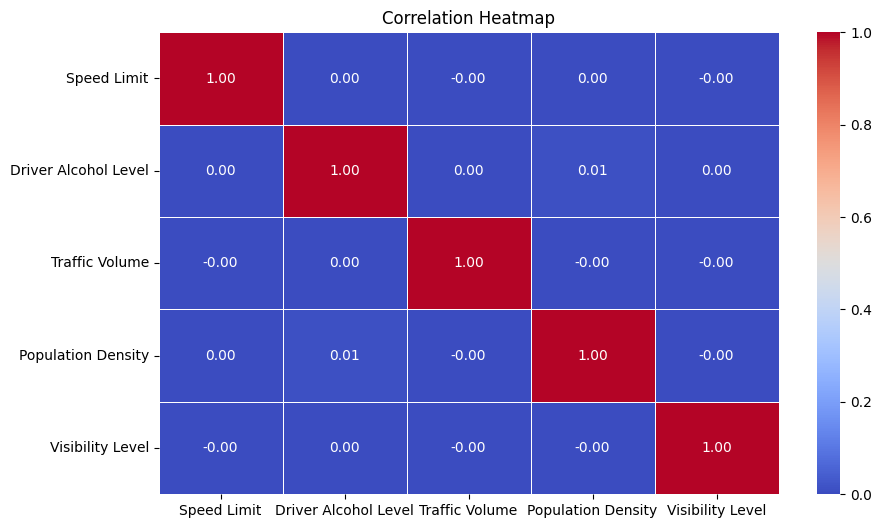

                      Speed Limit  Driver Alcohol Level  Traffic Volume  \
Speed Limit              1.000000              0.000760       -0.001970   
Driver Alcohol Level     0.000760              1.000000        0.003478   
Traffic Volume          -0.001970              0.003478        1.000000   
Population Density       0.001393              0.005116       -0.001889   
Visibility Level        -0.002504              0.002469       -0.002471   

                      Population Density  Visibility Level  
Speed Limit                     0.001393         -0.002504  
Driver Alcohol Level            0.005116          0.002469  
Traffic Volume                 -0.001889         -0.002471  
Population Density              1.000000         -0.000137  
Visibility Level               -0.000137          1.000000  


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
# List of columns to keep
columns_to_keep = [
    "Speed Limit",
    "Driver Alcohol Level",
    "Traffic Volume",
    "Population Density",
    "Visibility Level"
]

# Select only the desired columns
data_cleaned = df[columns_to_keep].copy()
data_cleaned.info()
data_cleaned.head()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()
# Compute correlation table
corr_table = data_cleaned.corr()
print(corr_table)

**Observation**: This reduces extremely high or low values without deleting data and ensures outliers do not distort the model and statistics. 

**Example**: If someone recorded speed as 900 km/h, it gets corrected.